In [ ]:


import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('/content/diabetes.csv')

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [ ]:
df.info()
# summart of all the df datatype , missing value etc

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
#  no non- null values in the Dataset

# cardinality -> number of unique disnitch values in single column
# low Cardinality its a cartegorical feature or outcome
df.nunique()

,0
Pregnancies,17
Glucose,136
BloodPressure,47
SkinThickness,51
Insulin,186
BMI,248
DiabetesPedigreeFunction,517
Age,52
Outcome,2


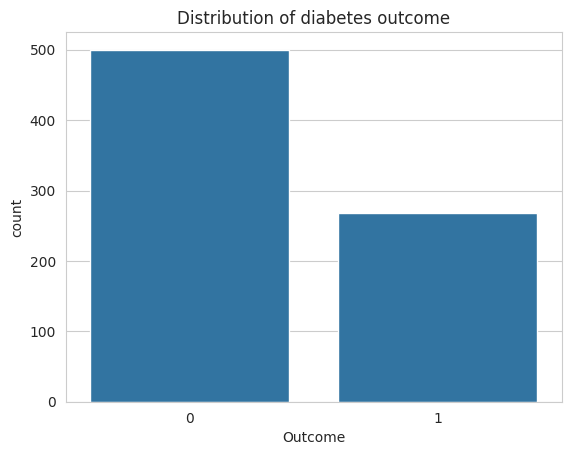

In [ ]:
#  check if the data is  balanced like if data set has 95% non-diabetic and 5% daibetitc the model will not learn more on no - diabetic data and hence
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

# a count plot fot the outcome column
# data --> tell what df to use to plot
#  x= 'outcome' the label on the grap
ax = sns.countplot(x='Outcome', data = df)

# title of the plot
ax.set_title("Distribution of diabetes outcome")

plt.show()

What can a histogram tell us?

- Central Tendency: Where is the center of the data? Is there a clear peak?
- Spread (Dispersion): Is the data tightly clustered or widely spread out?
- Shape and Skewness: Is the data symmetric (like a bell curve), or is it skewed, with a long tail on one side?
- Outliers: Are there small bars far away from the main group of data?

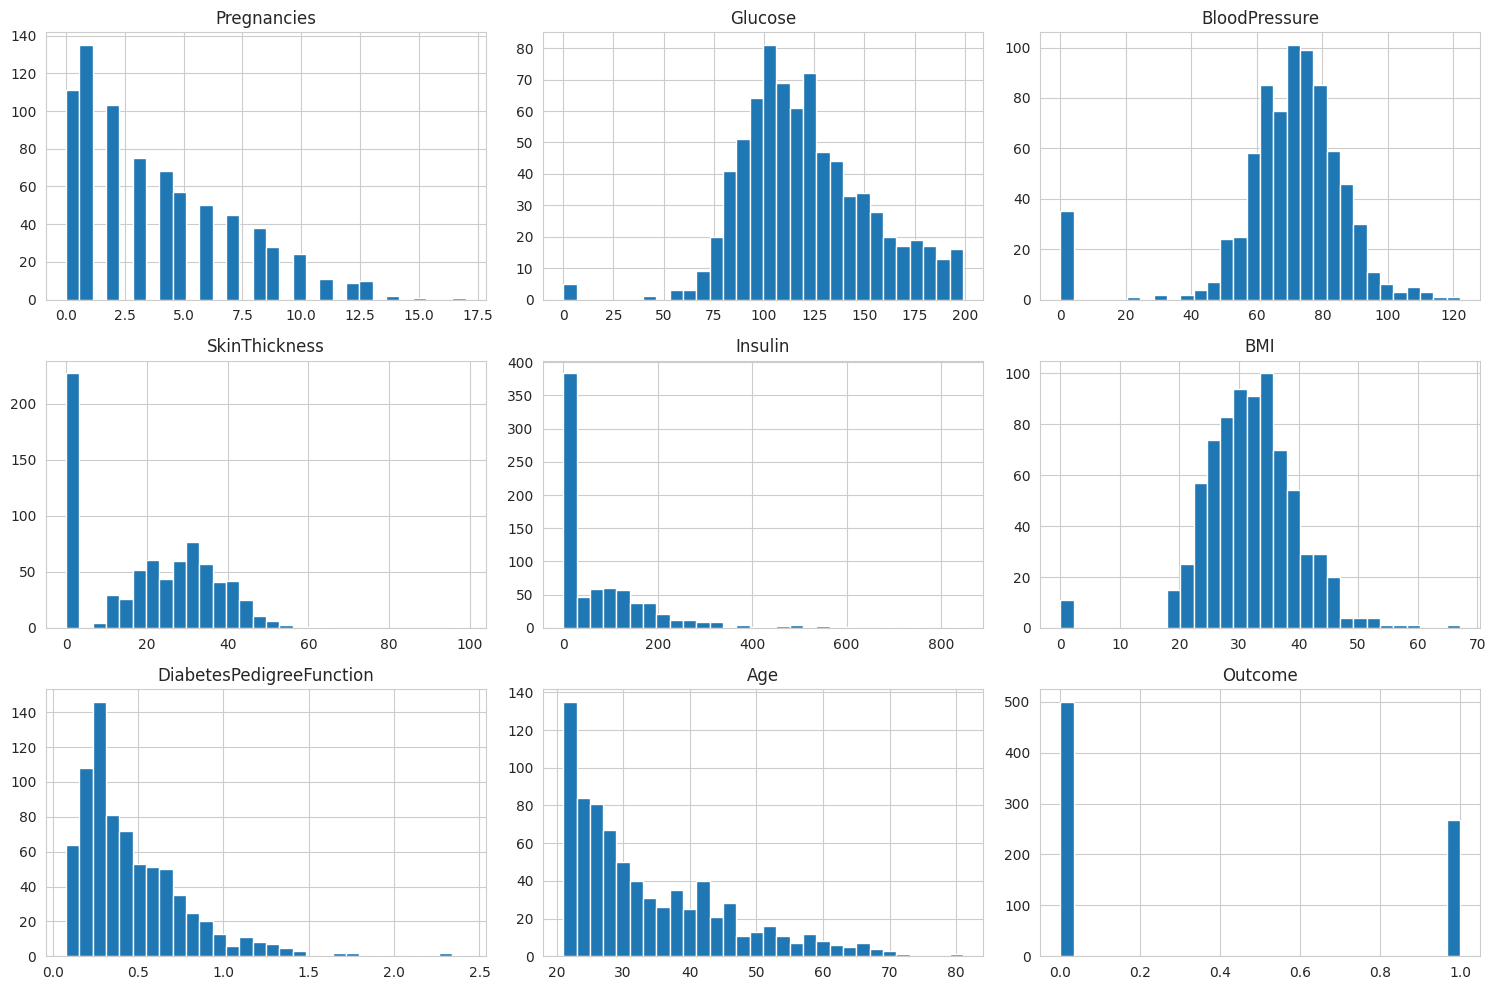

In [ ]:
df.hist(figsize=(15,10), bins= 30 , layout=(3,3))
#  (15,10 )--> overall size of the image
# bisn --> telling pandas to divide data for each feature into 30 equal bins
#  (3,3) --> arrange the 9 plots in 3x3 grod

plt.tight_layout()
#  auto adject the subplot to fit in the figure

plt.show()

Age and Pregnancies are also right-skewed, which is quite common in demographic data (there are typically more younger individuals than very old ones).

This visual skew confirms what we suspected when we saw the mean being significantly larger than the median (the 50% mark) in the .describe() output.

Normal-like" Distributions (Glucose, BloodPressure, BMI): If you mentally ignore the artificial spike at zero, the distributions for Glucose, BloodPressure, and BMI begin to resemble a Normal Distribution (a classic "bell curve"). This is a common and expected pattern for many physiological measurements. This insight is valuable because some machine learning models perform better when features have a normal-like distribution.

Outliears detection

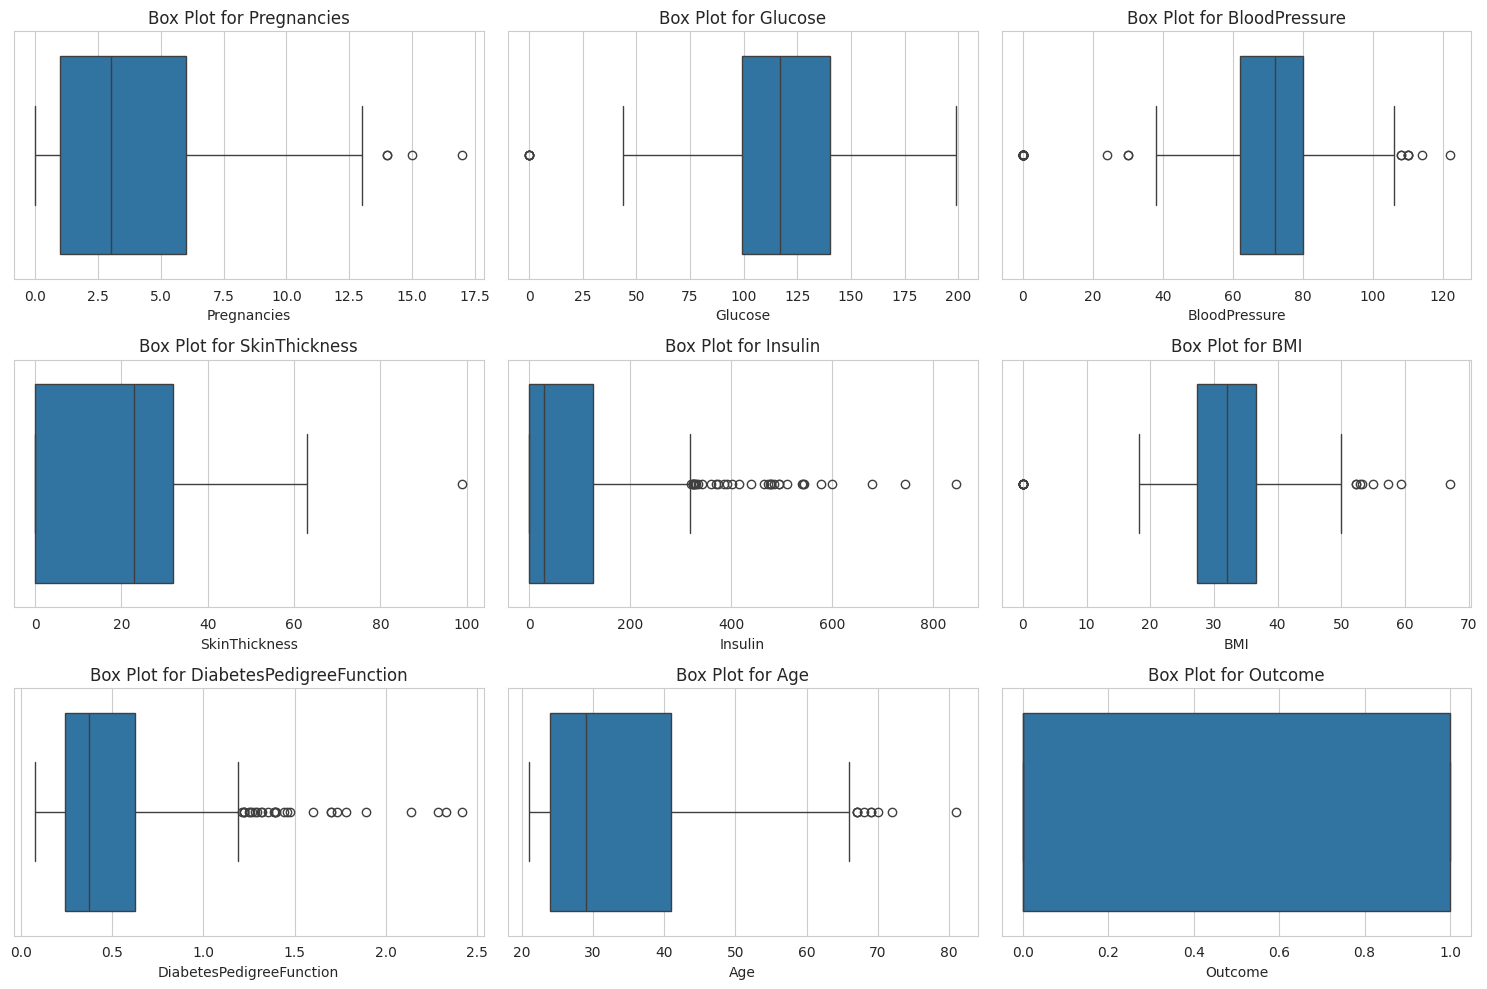

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))

#  grod of box plots to viz the distribution

# We use the flatten() method on the axes array to make it a 1D array, which is easier to loop over.
# We then loop through both the flattened axes and our DataFrame's columns simultaneously using zip().
for ax, col in zip(axes.flatten(), df.columns):
    # For each column, we create a box plot on its corresponding subplot (ax).
    # - data=df: The DataFrame containing our data.
    # - x=col: The column we want to plot.
    sns.boxplot(x=col, data=df, ax=ax)

    # We set a title for each subplot to know which feature it represents.
    ax.set_title(f'Box Plot for {col}')

# plt.tight_layout() adjusts the padding between and around subplots to prevent labels from overlapping.
plt.tight_layout()

# Display the entire grid of plots.
plt.show()

In [ ]:
correlation_matrix = df.corr()

correlation_matrix

#  Glucose has highest correction
#  while BMI , AGE mid


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


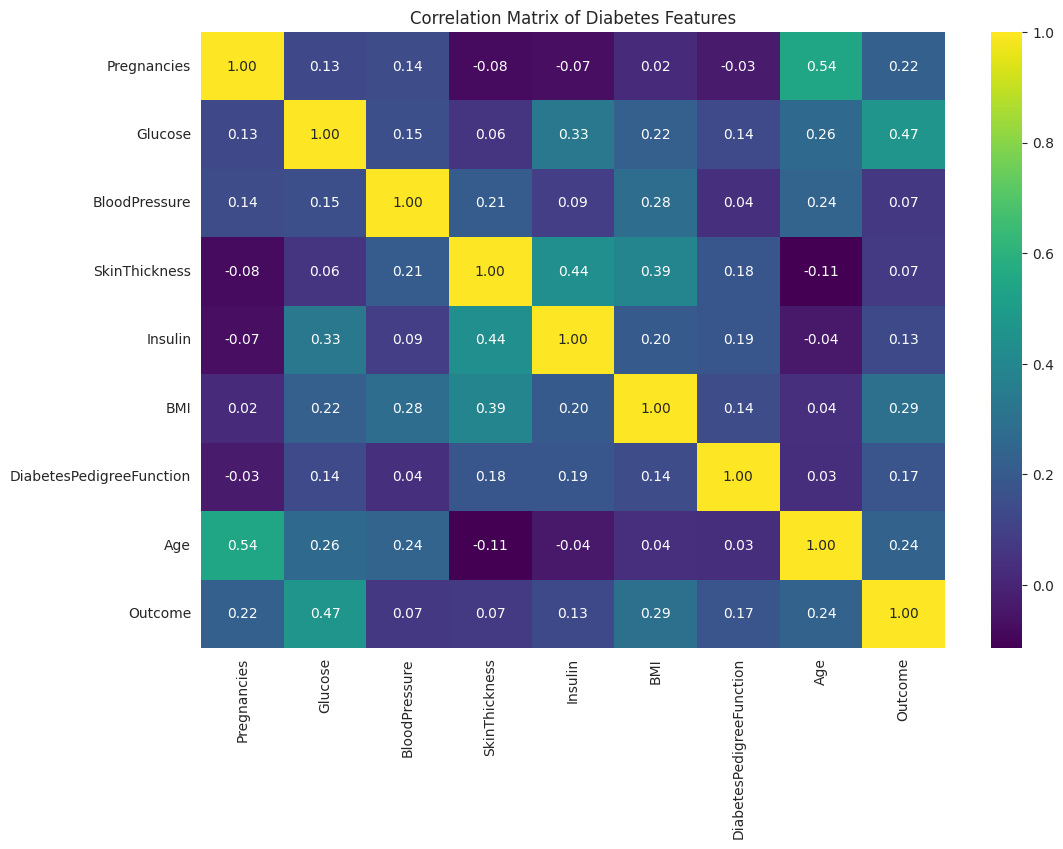

In [ ]:
# We'll create a larger figure to make our heatmap easy to read.
plt.figure(figsize=(12, 8))

# sns.heatmap() is the function we use to create the plot.
# - correlation_matrix: This is the data we're plotting.
# - annot=True: This is a crucial argument. It tells Seaborn to write the data value in each cell.
#   This gives us the best of both worlds: the easy visual interpretation of colors and the precise numerical value.
# - cmap='viridis': This sets the color map for the plot. 'viridis' is a popular choice because it's
#   visually appealing, performs well for people with color vision deficiencies, and prints well in grayscale.
# - fmt='.2f': This formats the annotations (the numbers in the cells) to two decimal places, which is clean and readable.
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt='.2f')

# Add a title for context.
plt.title('Correlation Matrix of Diabetes Features')

# Display the plot.
plt.show()

In [ ]:
# Based on our EDA and domain knowledge, we know that a value of 0 in these specific columns
# is not a valid measurement. It's a placeholder for missing data.
# We create a list of these column names to make it easy to work with them in the next steps.
columns_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# We can print the first few rows of just these columns to re-confirm the presence of 0s.
# Notice the 0s in 'SkinThickness' and 'Insulin' in row 2, and 'BloodPressure' in row 7 (if you view more rows).
print("A peek at the data in the identified columns:")
df[columns_with_zeros].head()

A peek at the data in the identified columns:


,Glucose,BloodPressure,SkinThickness,Insulin,BMI
0,148,72,35,0,33.6
1,85,66,29,0,26.6
2,183,64,0,0,23.3
3,89,66,23,94,28.1
4,137,40,35,168,43.1


In [ ]:
df[columns_with_zeros] = df[columns_with_zeros].replace(0,np.nan)

print("Data after replacing 0s with Nan")
df.head()

Data after replacing 0s with Nan


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [ ]:
missing_values_count = df.isnull().sum()
print(missing_values_count)


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


# Filling the missing values
- option 1 droppping data x as insulin has 300 values which is half of the entire dataset
- inputation with mean x mean is sensative towards outliers and skewed data
- median  proceed with this

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

imputer_data_array = imputer.fit_transform(df);

# numpy array back to pandas
df_imputed = pd.DataFrame(imputer_data_array , columns=df.columns)

print('Missing values after imputation')
print(df_imputed.head())

# IMP
df = df_imputed

Missing values after imputation
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0          6.0    148.0           72.0           35.0    125.0  33.6   
1          1.0     85.0           66.0           29.0    125.0  26.6   
2          8.0    183.0           64.0           29.0    125.0  23.3   
3          1.0     89.0           66.0           23.0     94.0  28.1   
4          0.0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction   Age  Outcome  
0                     0.627  50.0      1.0  
1                     0.351  31.0      0.0  
2                     0.672  32.0      1.0  
3                     0.167  21.0      0.0  
4                     2.288  33.0      1.0  


Separate the training and Test data

In [ ]:
X = df.drop('Outcome', axis=1)
# axis 1 column

y = df['Outcome'];

print(X.head())
print(y.head())
print(X.shape)
print(y.shape)


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0          6.0    148.0           72.0           35.0    125.0  33.6   
1          1.0     85.0           66.0           29.0    125.0  26.6   
2          8.0    183.0           64.0           29.0    125.0  23.3   
3          1.0     89.0           66.0           23.0     94.0  28.1   
4          0.0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction   Age  
0                     0.627  50.0  
1                     0.351  31.0  
2                     0.672  32.0  
3                     0.167  21.0  
4                     2.288  33.0  
0    1.0
1    0.0
2    1.0
3    0.0
4    1.0
Name: Outcome, dtype: float64
(768, 8)
(768,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2 , random_state=42, stratify=y)
# stratify = y --> imbalance outcome as there are many 0s and 1s so startify ensumes there are proportion of 0s and 1s

print("Shape of original X:", X.shape)
print("Shape of original y:", y.shape)
print("-" * 30)
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("-" * 30)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)


Shape of original X: (768, 8)
Shape of original y: (768,)
------------------------------
Shape of X_train: (614, 8)
Shape of y_train: (614,)
------------------------------
Shape of X_test: (154, 8)
Shape of y_test: (154,)


Scaling of data

In [ ]:
#  age range 21 to 81
# glucose 44 to 199
# inculine double digit to 800

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

#  fit the scaler fxn into train and test data

scaler.fit(X_train)
print("Learned Mean values for each feature (from X_train):")
print(scaler.mean_)

# The `scaler.scale_` attribute holds an array of the standard deviation values for each feature.
print("\nLearned Standard Deviation values for each feature (from X_train):")
print(scaler.scale_)



Learned Mean values for each feature (from X_train):
[  3.81921824 121.67100977  72.14006515  29.04234528 137.70521173
  32.44674267   0.47742834  33.36644951]

Learned Standard Deviation values for each feature (from X_train):
[ 3.31144822 29.97935076 12.26511926  8.88461128 78.70059997  6.81858312
  0.33003119 11.8237979 ]


In [ ]:
# 1. Transform the training data
# The scaler uses the means and standard deviations it learned from X_train to scale X_train.
X_train_scaled = scaler.transform(X_train)

# 2. Transform the testing data
# CRUCIALLY, we use the same scaler (fitted on X_train) to transform X_test.
# This ensures the test set is scaled according to the same rules as the training set.
X_test_scaled = scaler.transform(X_test)

# --- Verification ---
# The output of the transform method is a NumPy array. Let's convert it back to a pandas DataFrame
# so we can easily inspect it and verify the results. We pass the original column names.
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Let's look at the first few rows of our newly scaled training data.
# Notice how the values are now both positive and negative, centered around zero.
print("First 5 rows of scaled training data (X_train_scaled):")
print(X_train_scaled.head())

# The definitive proof of successful standardization is to check the new mean and standard deviation.
# We'll use .describe() on our scaled training data.
print("\nStatistical summary of scaled training data:")
print(X_train_scaled.describe())

First 5 rows of scaled training data (X_train_scaled):
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0    -0.851355 -1.056427      -0.826740      -1.918187 -1.203361 -0.769477   
1     0.356576  0.144399       0.477772      -0.229874 -1.470195 -0.417498   
2    -0.549372 -0.556083      -1.152868       1.233330 -0.555335  0.359790   
3    -0.851355  0.811525      -1.315932      -0.004766 -0.161437 -0.402832   
4    -1.153338 -0.889646      -0.663676       1.120776 -0.415565  1.782373   

   DiabetesPedigreeFunction       Age  
0                  0.310794 -0.792169  
1                 -0.116439  0.561034  
2                 -0.764862 -0.707594  
3                  0.262314 -0.369293  
4                 -0.337630 -0.961320  

Statistical summary of scaled training data:
        Pregnancies       Glucose  BloodPressure  SkinThickness       Insulin  \
count  6.140000e+02  6.140000e+02   6.140000e+02   6.140000e+02  6.140000e+02   
mean  -6.943414e-17 -1.09937

# Model training


In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42)

# The .fit() method is the core of model training in Scikit-learn.
# It takes the training features (X) and the training target (y) as input.
# - X_train_scaled: Our preprocessed, scaled training data. This is the "what to learn from".
# - y_train: Our corresponding training labels. This is the "what to predict".
# The model will learn the relationship between these two datasets.
# The .fit() method modifies the `log_reg` object in-place, filling it with the learned parameters (coefficients).
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [ ]:
# We are importing the KNeighborsClassifier class from Scikit-learn's neighbors module.
# - sklearn: The top-level library.
# - neighbors: The module containing algorithms that make predictions based on the proximity of data points.
# - KNeighborsClassifier: The specific class that provides the blueprint for our k-NN model.
from sklearn.neighbors import KNeighborsClassifier

# Print a confirmation message to ensure the import was successful.
print("KNeighborsClassifier class imported successfully.")

KNeighborsClassifier class imported successfully.


In [ ]:
# Create an instance of the KNeighborsClassifier class.
# The most important hyperparameter is `n_neighbors`, which is the 'k' in k-NN.
# We are setting it to 5, which is a common and effective starting value.
# This means for any new prediction, the model will find the 5 closest points in the training data and take a majority vote.
knn = KNeighborsClassifier(n_neighbors=5)

# Let's print the object to see that it has been created successfully.
# This will display all the default hyperparameters it has been configured with.
print("K-Nearest Neighbors model initialized successfully:")
print(knn)

K-Nearest Neighbors model initialized successfully:
KNeighborsClassifier()


In [ ]:
# The .fit() method for k-NN is its "training" step.
# For this algorithm, it doesn't learn complex parameters like Logistic Regression does.
# Instead, it simply loads the entire training dataset (both features and labels) into memory.
# This memorized data will be used later to find the nearest neighbors for new data points.
knn.fit(X_train_scaled, y_train)

# After fitting, we can print the model object again to confirm the process is complete.
# The object is now a "fitted" estimator, ready to make predictions.
print("K-Nearest Neighbors model has been successfully trained (fitted).")
print(knn)

K-Nearest Neighbors model has been successfully trained (fitted).
KNeighborsClassifier()


In [ ]:
# The .predict() method uses the trained model to make predictions on new, unseen data.
# We pass it our scaled test features (X_test_scaled).
# The model has never seen this data before, so this is an honest test of its performance.
# The output will be a NumPy array containing the model's predicted class (0 or 1) for each patient in the test set.
y_pred_log_reg = log_reg.predict(X_test_scaled)

# --- Verification ---
# It's always a good practice to inspect the output of our operations.

# 1. Let's look at the first 20 predictions our model made.
# This array is our model's "answer sheet" for the test set.
print("First 20 predictions from the Logistic Regression model:")
print(y_pred_log_reg[:20])

# 2. Let's look at the first 20 true labels from our test set to compare.
# This is the "official answer key".
print("\nFirst 20 true labels (y_test):")
print(y_test[:20].values) # .values converts the pandas Series to a NumPy array for a clean comparison

# 3. A critical sanity check is to ensure the number of predictions matches the number of true labels.
# The shapes of both arrays should be identical.
print(f"\nShape of predictions array (y_pred_log_reg): {y_pred_log_reg.shape}")
print(f"Shape of true labels array (y_test): {y_test.shape}")

First 20 predictions from the Logistic Regression model:
[1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0.]

First 20 true labels (y_test):
[0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0.]

Shape of predictions array (y_pred_log_reg): (154,)
Shape of true labels array (y_test): (154,)


--- Logistic Regression Classification Report ---
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.75      0.82      0.78       100
    Diabetic (1)       0.60      0.50      0.55        54

        accuracy                           0.71       154
       macro avg       0.68      0.66      0.67       154
    weighted avg       0.70      0.71      0.70       154

\n--- Logistic Regression Confusion Matrix ---


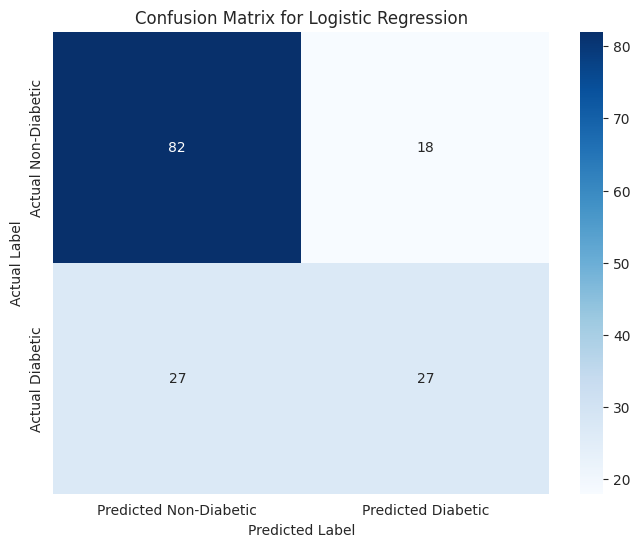

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("--- Logistic Regression Classification Report ---")
# The target_names parameter allows us to label our classes for better readability.
print(classification_report(y_test, y_pred_log_reg, target_names=['Non-Diabetic (0)', 'Diabetic (1)']))

# --- Generate and Visualize the Confusion Matrix ---
print("\\n--- Logistic Regression Confusion Matrix ---")
# First, we compute the confusion matrix which returns a 2x2 numpy array
cm = confusion_matrix(y_test, y_pred_log_reg)

# Now, we use seaborn's heatmap to visualize this matrix
plt.figure(figsize=(8, 6)) # Set the figure size for better readability
sns.heatmap(cm,
            annot=True,      # Annotate the cells with the numeric value
            fmt='d',         # Format the numbers as integers
            cmap='Blues',    # Use a blue color map
            xticklabels=['Predicted Non-Diabetic', 'Predicted Diabetic'],
            yticklabels=['Actual Non-Diabetic', 'Actual Diabetic'])

plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

In [ ]:
y_pred_knn = knn.predict(X_test_scaled)

# --- Verification ---
# As before, let's inspect the results to ensure everything worked as expected.

# 1. Look at the first 20 predictions from our k-NN model.
# Compare this "answer sheet" to the one generated by the Logistic Regression model.
print("First 20 predictions from the k-NN model:")
print(y_pred_knn[:20])

# 2. Look at the first 20 true labels from our test set again for comparison.
# This is the same "official answer key" as before.
print("\nFirst 20 true labels (y_test):")
print(y_test[:20].values) # Using .values for a clean NumPy array comparison

# 3. Verify that the number of k-NN predictions matches the number of true labels.
# This confirms we have a prediction for every sample in our test set.
print(f"\nShape of k-NN predictions array (y_pred_knn): {y_pred_knn.shape}")
print(f"Shape of true labels array (y_test): {y_test.shape}")

First 20 predictions from the k-NN model:
[1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 1. 0. 1. 0.]

First 20 true labels (y_test):
[0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0.]

Shape of k-NN predictions array (y_pred_knn): (154,)
Shape of true labels array (y_test): (154,)


--- K-Nearest Neighbors (k-NN) Classification Report ---
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.80      0.83      0.81       100
    Diabetic (1)       0.66      0.61      0.63        54

        accuracy                           0.75       154
       macro avg       0.73      0.72      0.72       154
    weighted avg       0.75      0.75      0.75       154


--- K-Nearest Neighbors (k-NN) Confusion Matrix ---


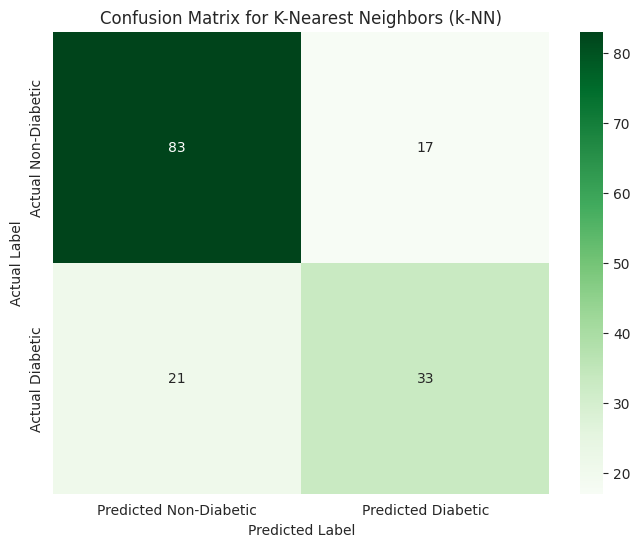

In [ ]:
print("--- K-Nearest Neighbors (k-NN) Classification Report ---")
print(classification_report(y_test, y_pred_knn, target_names=['Non-Diabetic (0)', 'Diabetic (1)']))

# --- Generate and Visualize the Confusion Matrix for the k-NN Model ---
print("\n--- K-Nearest Neighbors (k-NN) Confusion Matrix ---")
# Compute the confusion matrix using the k-NN predictions
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn,
            annot=True,
            fmt='d',
            cmap='Greens', # Using a different color map to visually distinguish from the last plot
            xticklabels=['Predicted Non-Diabetic', 'Predicted Diabetic'],
            yticklabels=['Actual Non-Diabetic', 'Actual Diabetic'])

plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix for K-Nearest Neighbors (k-NN)')
plt.show()

In [ ]:
# F1-Score = 2 * (Precision * Recall) / (Precision + Recall)
from sklearn.metrics import classification_report

In [ ]:
report_log_re =classification_report(y_test,y_pred_log_reg,target_names=['Non Diabetic(0)', 'Diabetic (1)'],output_dict=True)

report_knn = classification_report(y_test,y_pred_knn,target_names=['Non Diabetic(0)', 'Diabetic (1)'],output_dict=True)

#  cal the f1

f1_log_reg = report_log_re['Diabetic (1)']['f1-score']
f1_knn = report_knn['Diabetic (1)']['f1-score']

print(f"--- F1-Score Comparison ---")
print(f"Logistic Regression F1-Score (Diabetic Class): {f1_log_reg:.4f}")
print(f"K-Nearest Neighbors F1-Score (Diabetic Class): {f1_knn:.4f}")

print("\\n--- Initial Conclusion ---")
if f1_log_reg > f1_knn:
    print("Based on the F1-Score, the Logistic Regression model is the initial best performer.")
elif f1_knn > f1_log_reg:
    print("Based on the F1-Score, the K-Nearest Neighbors model is the initial best performer.")
else:
    print("Based on the F1-Score, both models have nearly identical performance.")

--- F1-Score Comparison ---
Logistic Regression F1-Score (Diabetic Class): 0.5455
K-Nearest Neighbors F1-Score (Diabetic Class): 0.6346
\n--- Initial Conclusion ---
Based on the F1-Score, the K-Nearest Neighbors model is the initial best performer.


In [ ]:
# Assuming you still have the confusion matrix numpy arrays from the previous tasks:
# cm for Logistic Regression
# cm_knn for K-Nearest Neighbors

# The confusion matrix from sklearn has the layout: [[TN, FP], [FN, TP]]
# So we can access the counts by their index.
# Top-Right is False Positives (FP) at index [0, 1]
# Bottom-Left is False Negatives (FN) at index [1, 0]

# --- Extracting counts for Logistic Regression ---
tn_log_reg = cm[0, 0]
fp_log_reg = cm[0, 1]
fn_log_reg = cm[1, 0]
tp_log_reg = cm[1, 1]

# --- Extracting counts for K-Nearest Neighbors ---
tn_knn = cm_knn[0, 0]
fp_knn = cm_knn[0, 1]
fn_knn = cm_knn[1, 0]
tp_knn = cm_knn[1, 1]

# --- Printing a clear, comparative analysis ---
print("--- Error Analysis: Logistic Regression vs. k-NN ---")
print("\\n--- Logistic Regression ---")
print(f"False Positives (Predicted Diabetic, Was Healthy): {fp_log_reg}")
print(f"False Negatives (Predicted Healthy, Was Diabetic): {fn_log_reg}  <-- MOST CRITICAL ERROR")

print("\\n--- K-Nearest Neighbors ---")
print(f"False Positives (Predicted Diabetic, Was Healthy): {fp_knn}")
print(f"False Negatives (Predicted Healthy, Was Diabetic): {fn_knn}  <-- MOST CRITICAL ERROR")

print("\\n--- Final Conclusion ---")
if fn_log_reg < fn_knn:
    print(f"The Logistic Regression model is the superior baseline.")
    print(f"It produced {fn_knn - fn_log_reg} fewer False Negatives, which is our primary concern.")
elif fn_knn < fn_log_reg:
    print(f"The K-Nearest Neighbors model is the superior baseline.")
    print(f"It produced {fn_log_reg - fn_knn} fewer False Negatives, which is our primary concern.")
else:
    print("Both models produced the same number of False Negatives.")
    print("We can fall back to the F1-score to make our final decision.")


--- Error Analysis: Logistic Regression vs. k-NN ---
\n--- Logistic Regression ---
False Positives (Predicted Diabetic, Was Healthy): 18
False Negatives (Predicted Healthy, Was Diabetic): 27  <-- MOST CRITICAL ERROR
\n--- K-Nearest Neighbors ---
False Positives (Predicted Diabetic, Was Healthy): 17
False Negatives (Predicted Healthy, Was Diabetic): 21  <-- MOST CRITICAL ERROR
\n--- Final Conclusion ---
The K-Nearest Neighbors model is the superior baseline.
It produced 6 fewer False Negatives, which is our primary concern.


In [ ]:
from sklearn.ensemble import RandomForestClassifier



In [ ]:
# n_estimators --> numner of random tree
rf_model = RandomForestClassifier(n_estimators = 100, random_state =42,n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:

from xgboost import XGBClassifier



In [ ]:
from xgboost import XGBClassifier

In [ ]:
# - n_estimators=100: We will build a sequence of 100 trees.
# - learning_rate=0.1: We'll use a slightly more conservative learning rate than the default (0.3).
#   This often leads to better generalization. It's a good starting point for tuning later.
# - random_state=42: Ensures our results are perfectly reproducible.
# - use_label_encoder=False and eval_metric='logloss': These are modern best practices to ensure
#   our code is clean and free of potential warnings from the library.
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss')

# --- Train the XGBoost Model ---
# We call the .fit() method, passing our scaled training data.
# The model will now begin its sequential training process: building tree after tree,
# with each new tree focused on correcting the errors of its predecessors.
xgb_model.fit(X_train_scaled ,y_train)

# Print a confirmation message. The xgb_model object is now a fully trained,
# highly optimized, and powerful classification model.
print("XGBoost model initialized and trained successfully:")
print(xgb_model)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:23:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model initialized and trained successfully:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)


--- Random Forest Classifier Report ---
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.81      0.87      0.84       100
    Diabetic (1)       0.72      0.61      0.66        54

        accuracy                           0.78       154
       macro avg       0.76      0.74      0.75       154
    weighted avg       0.77      0.78      0.77       154


--- Random Forest Confusion Matrix ---


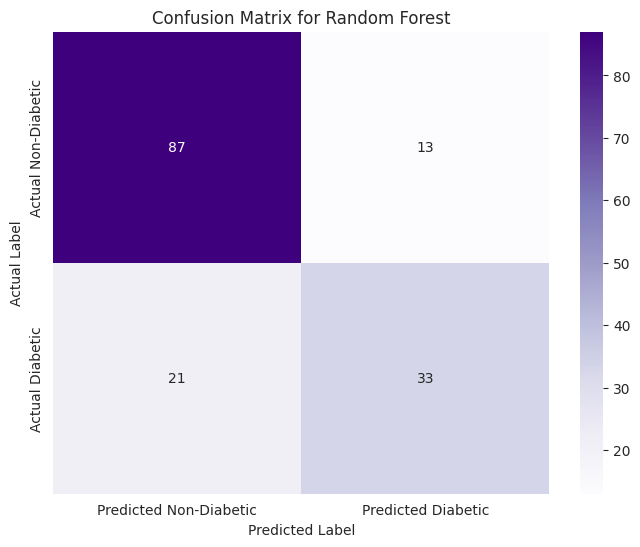

In [ ]:
# --- 1. Make predictions with the trained Random Forest model ---
# We use the .predict() method on our unseen test data (X_test_scaled).
y_pred_rf = rf_model.predict(X_test_scaled)

# --- 2. Generate the Classification Report for the Random Forest ---
print("--- Random Forest Classifier Report ---")
print(classification_report(y_test, y_pred_rf, target_names=['Non-Diabetic (0)', 'Diabetic (1)']))

# --- 3. Generate and Visualize the Confusion Matrix for the Random Forest ---
print("\n--- Random Forest Confusion Matrix ---")
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Purples', # Using a new color map to distinguish from baselines
            xticklabels=['Predicted Non-Diabetic', 'Predicted Diabetic'],
            yticklabels=['Actual Non-Diabetic', 'Actual Diabetic'])

plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix for Random Forest')
plt.show()



--- XGBoost Classifier Report ---
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.79      0.83      0.81       100
    Diabetic (1)       0.65      0.59      0.62        54

        accuracy                           0.75       154
       macro avg       0.72      0.71      0.72       154
    weighted avg       0.74      0.75      0.74       154


--- XGBoost Confusion Matrix ---


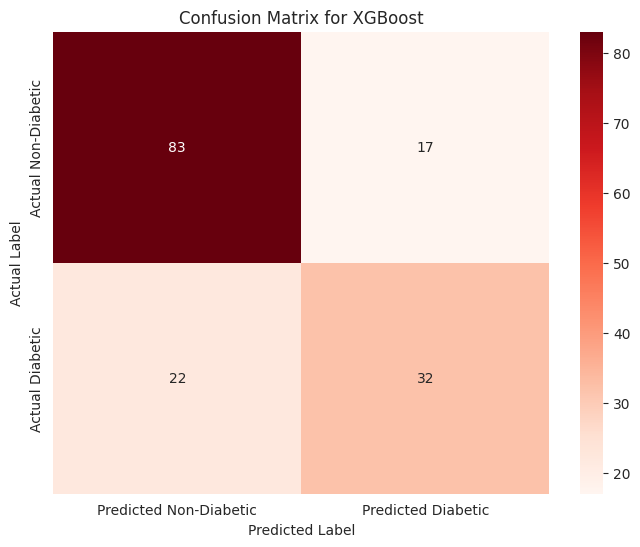

In [ ]:
# --- 1. Make predictions with the trained XGBoost model ---
# We use the .predict() method, just like with all our other models.
y_pred_xgb = xgb_model.predict(X_test_scaled)

# --- 2. Generate the Classification Report for XGBoost ---
print("\n\n--- XGBoost Classifier Report ---")
print(classification_report(y_test, y_pred_xgb, target_names=['Non-Diabetic (0)', 'Diabetic (1)']))

# --- 3. Generate and Visualize the Confusion Matrix for XGBoost ---
print("\n--- XGBoost Confusion Matrix ---")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb,
            annot=True,
            fmt='d',
            cmap='Reds', # Another distinct color map
            xticklabels=['Predicted Non-Diabetic', 'Predicted Diabetic'],
            yticklabels=['Actual Non-Diabetic', 'Actual Diabetic'])

plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix for XGBoost')
plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# We already have the predictions: y_pred_log_reg, y_pred_knn, y_pred_rf, y_pred_xgb
# We also have the ground truth: y_test

# --- Step 1: Get Classification Reports as Dictionaries ---
# The output_dict=True parameter is the key to easily extracting specific scores.
report_log_reg = classification_report(y_test, y_pred_log_reg, target_names=['Non-Diabetic (0)', 'Diabetic (1)'], output_dict=True)
report_knn = classification_report(y_test, y_pred_knn, target_names=['Non-Diabetic (0)', 'Diabetic (1)'], output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, target_names=['Non-Diabetic (0)', 'Diabetic (1)'], output_dict=True)
report_xgb = classification_report(y_test, y_pred_xgb, target_names=['Non-Diabetic (0)', 'Diabetic (1)'], output_dict=True)

# --- Step 2: Extract Metrics for the 'Diabetic (1)' Class ---
# We will create a dictionary to hold all our results.
performance_summary = {
    'Logistic Regression': {
        'Precision': report_log_reg['Diabetic (1)']['precision'],
        'Recall': report_log_reg['Diabetic (1)']['recall'],
        'F1-Score': report_log_reg['Diabetic (1)']['f1-score'],
    },
    'K-Nearest Neighbors': {
        'Precision': report_knn['Diabetic (1)']['precision'],
        'Recall': report_knn['Diabetic (1)']['recall'],
        'F1-Score': report_knn['Diabetic (1)']['f1-score'],
    },
    'Random Forest': {
        'Precision': report_rf['Diabetic (1)']['precision'],
        'Recall': report_rf['Diabetic (1)']['recall'],
        'F1-Score': report_rf['Diabetic (1)']['f1-score'],
    },
    'XGBoost': {
        'Precision': report_xgb['Diabetic (1)']['precision'],
        'Recall': report_xgb['Diabetic (1)']['recall'],
        'F1-Score': report_xgb['Diabetic (1)']['f1-score'],
    }
}

# --- Step 3: Extract False Positives and False Negatives from Confusion Matrices ---
# The confusion matrices are 2x2 arrays: [[TN, FP], [FN, TP]]
# We can use the variables cm, cm_knn, cm_rf, cm_xgb you created earlier.
all_cms = {
    'Logistic Regression': cm,
    'K-Nearest Neighbors': cm_knn,
    'Random Forest': cm_rf,
    'XGBoost': cm_xgb
}

for model_name, model_cm in all_cms.items():
    performance_summary[model_name]['False Positives'] = model_cm[0, 1]
    performance_summary[model_name]['False Negatives'] = model_cm[1, 0]

# --- Step 4: Convert the Dictionary to a Pandas DataFrame for Beautiful Display ---
performance_df = pd.DataFrame.from_dict(performance_summary, orient='index')

# Let's reorder the columns to our preferred layout
performance_df = performance_df[['F1-Score', 'Recall', 'Precision', 'False Negatives', 'False Positives']]

# --- Step 5: Display the Final Performance Dashboard ---
print("--- Model Performance Comparison ---")
display(performance_df.style.background_gradient(cmap='viridis', subset=['F1-Score', 'Recall'])
                          .highlight_min(subset=['False Negatives'], color='lightcoral'))


--- Model Performance Comparison ---


,F1-Score,Recall,Precision,False Negatives,False Positives
Logistic Regression,0.545455,0.500000,0.600000,27,18
K-Nearest Neighbors,0.634615,0.611111,0.660000,21,17
Random Forest,0.660000,0.611111,0.717391,21,13
XGBoost,0.621359,0.592593,0.653061,22,17


In [ ]:

best_model = rf_model


best_model_name = "Random Forest"

print(f"The selected best performing model is: {best_model_name}")
print("This model will be used for the next step: Hyperparameter Tuning.")

The selected best performing model is: Random Forest
This model will be used for the next step: Hyperparameter Tuning.


In [ ]:
# --- Alternative: Define the Parameter Grid for Random Forest ---

param_grid_rf = {
    # n_estimators: The number of trees in the forest.
    'n_estimators': [100, 200, 300],

    # max_depth: The maximum depth of the tree.
    'max_depth': [5, 10, 15, None], # 'None' means nodes are expanded until all leaves are pure.

    # min_samples_split: The minimum number of samples required to split an internal node.
    'min_samples_split': [2, 5, 10],

    # min_samples_leaf: The minimum number of samples required to be at a leaf node.
    'min_samples_leaf': [1, 2, 4],

    # max_features: The number of features to consider when looking for the best split.
    # 'sqrt' is a common and effective choice. 'auto' is the same as 'sqrt'.
    'max_features': ['sqrt', 'log2']
}

num_combinations = 1
for key in param_grid_rf:
    num_combinations *= len(param_grid_rf[key])
print(f"\nTotal number of combinations to test: {num_combinations}")


Total number of combinations to test: 216


GridSearch CV

In [ ]:
from sklearn.model_selection import GridSearchCV
# estimator --> master chef  pass the best model
# param_grid --> reciepe book pass the param_grid_rf reasd and understand the test of evey combination

In [ ]:
grid_search = GridSearchCV(
    estimator = best_model,
    param_grid = param_grid_rf,
    scoring = 'f1',
    cv = 5,
    verbose = 1,
    n_jobs = -1
)

print("--- GridSearchCV Tuning Engine Assembled and Ready ---")
print(grid_search)

--- GridSearchCV Tuning Engine Assembled and Ready ---
GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='f1', verbose=1)


In [ ]:
# Traning the GridSearchCV
grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='f1', verbose=1)

In [ ]:
print("--- Optimal Hyperparameters Found by Grid Search ---")
best_params = grid_search.best_params_
print(best_params)

--- Optimal Hyperparameters Found by Grid Search ---
{'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [ ]:
best_cv_score = grid_search.best_score_

print("--- Best Cross-Validation Score from Tuning ---")
print(f"The best average F1-score achieved during 5-fold cross-validation was: {best_cv_score:.4f}")

# To truly appreciate the effect of tuning, let's compare this score to the F1-score
# of our original, untuned model from the performance dashboard we created earlier.
# This assumes you have the 'performance_df' DataFrame and 'best_model_name' variable from previous tasks.
try:
    original_f1_score = performance_df.loc[best_model_name, 'F1-Score']

    print(f"\n--- Performance Improvement Analysis ---")
    print(f"Original, untuned model's F1-score on the test set: {original_f1_score:.4f}")
    print(f"Tuned model's cross-validation F1-score: {best_cv_score:.4f}")

    improvement = best_cv_score - original_f1_score
    # Using a format specifier with '+' shows the sign, making improvements obvious.
    print(f"Improvement from hyperparameter tuning: {improvement:+.4f}")

except NameError:
    print("\nRun the previous steps to create 'performance_df' and 'best_model_name' for a full comparison.")


--- Best Cross-Validation Score from Tuning ---
The best average F1-score achieved during 5-fold cross-validation was: 0.6584

--- Performance Improvement Analysis ---
Original, untuned model's F1-score on the test set: 0.6600
Tuned model's cross-validation F1-score: 0.6584
Improvement from hyperparameter tuning: -0.0016


--- The Final Tuned Model ---
RandomForestClassifier(max_depth=10, max_features='log2', min_samples_split=5,
                       n_jobs=-1, random_state=42)


--- Final Tuned Model Classification Report (on Test Set) ---
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.79      0.84      0.82       100
    Diabetic (1)       0.67      0.59      0.63        54

        accuracy                           0.75       154
       macro avg       0.73      0.72      0.72       154
    weighted avg       0.75      0.75      0.75       154


--- Final Tuned Model Confusion Matrix (on Test Set) ---


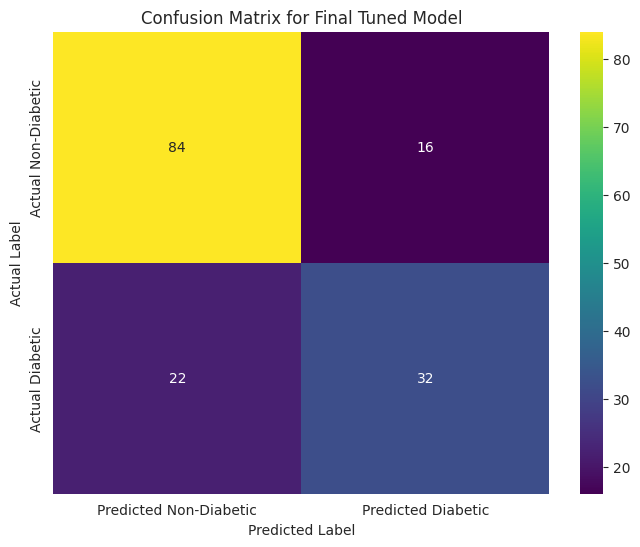



--- Performance Showdown: Tuned vs. Untuned Model on the Test Set ---


,Original Random Forest,Final Tuned Random Forest
Metric,,
F1-Score,0.6600,0.6275
Recall,0.6111,0.5926
False Negatives (Critical),21,22


In [ ]:
final_model = grid_search.best_estimator_

print("--- The Final Tuned Model ---")
print(final_model)

# --- 2. Make predictions on the test set using the final model ---
y_pred_final = final_model.predict(X_test_scaled)

# --- 3. Generate the Classification Report for the final model ---
print("\n\n--- Final Tuned Model Classification Report (on Test Set) ---")
# Let's get the report as a dictionary for easy comparison later
report_final = classification_report(y_test, y_pred_final, target_names=['Non-Diabetic (0)', 'Diabetic (1)'], output_dict=True)
print(classification_report(y_test, y_pred_final, target_names=['Non-Diabetic (0)', 'Diabetic (1)']))

# --- 4. Generate and Visualize the Confusion Matrix for the final model ---
print("\n--- Final Tuned Model Confusion Matrix (on Test Set) ---")
cm_final = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_final,
            annot=True,
            fmt='d',
            cmap='viridis', # A nice, vibrant colormap for our final model
            xticklabels=['Predicted Non-Diabetic', 'Predicted Diabetic'],
            yticklabels=['Actual Non-Diabetic', 'Actual Diabetic'])

plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix for Final Tuned Model')
plt.show()

# --- 5. The Ultimate Comparison: Tuned vs. Untuned ---
print("\n\n--- Performance Showdown: Tuned vs. Untuned Model on the Test Set ---")

# Extract metrics for the final tuned model
final_f1 = report_final['Diabetic (1)']['f1-score']
final_recall = report_final['Diabetic (1)']['recall']
final_fn = cm_final[1, 0] # False Negatives

# Get metrics for the original, untuned model from our dashboard
# This assumes 'performance_df' and 'best_model_name' are still in memory
original_f1 = performance_df.loc[best_model_name, 'F1-Score']
original_recall = performance_df.loc[best_model_name, 'Recall']
original_fn = performance_df.loc[best_model_name, 'False Negatives']

# Create a new DataFrame for a clear, side-by-side comparison
comparison_data = {
    'Metric': ['F1-Score', 'Recall', 'False Negatives (Critical)'],
    f'Original {best_model_name}': [original_f1, original_recall, original_fn],
    f'Final Tuned {best_model_name}': [final_f1, final_recall, final_fn]
}
comparison_df = pd.DataFrame(comparison_data)
comparison_df.set_index('Metric', inplace=True)

# Display the comparison table with styling
display(comparison_df.style.format('{:.4f}', subset=pd.IndexSlice[['F1-Score', 'Recall'], :])
                          .format('{:.0f}', subset=pd.IndexSlice[['False Negatives (Critical)'], :])
                          .background_gradient(cmap='Greens', axis=1, subset=pd.IndexSlice[['F1-Score', 'Recall'], :])
                          .highlight_min(subset=pd.IndexSlice[['False Negatives (Critical)'], :], color='lightcoral', axis=1))


# Model Interpretation
 high F1 is great in health care we need the reason why a particular  person was diabetic --> high glucose or high BMI etc

In [ ]:
importances = final_model.feature_importances_
#  this tells us the imp feature from the final_model its a numpy array

# We get the feature names from the columns of our original feature DataFrame 'X'.
# This assumes 'X' is the pandas DataFrame you created before splitting the data.
feature_names = X.columns

# Creating a  pandas DF to hold the DF and importance
feature_importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# SORT
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

# Display
print("FINAL MODEL")
display(feature_importances_df.reset_index(drop = True))

FINAL MODEL


,Feature,Importance
0,Glucose,0.322654
1,BMI,0.169798
2,Age,0.116227
3,DiabetesPedigreeFunction,0.115511
4,Insulin,0.084228
5,Pregnancies,0.071802
6,BloodPressure,0.060888
7,SkinThickness,0.058892


Visualizing Feature Importance

/tmp/ipython-input-312/3216393408.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Importance', y ='Feature' , data = feature_importances_df,palette='viridis')


ValueError: Format specifier missing precision

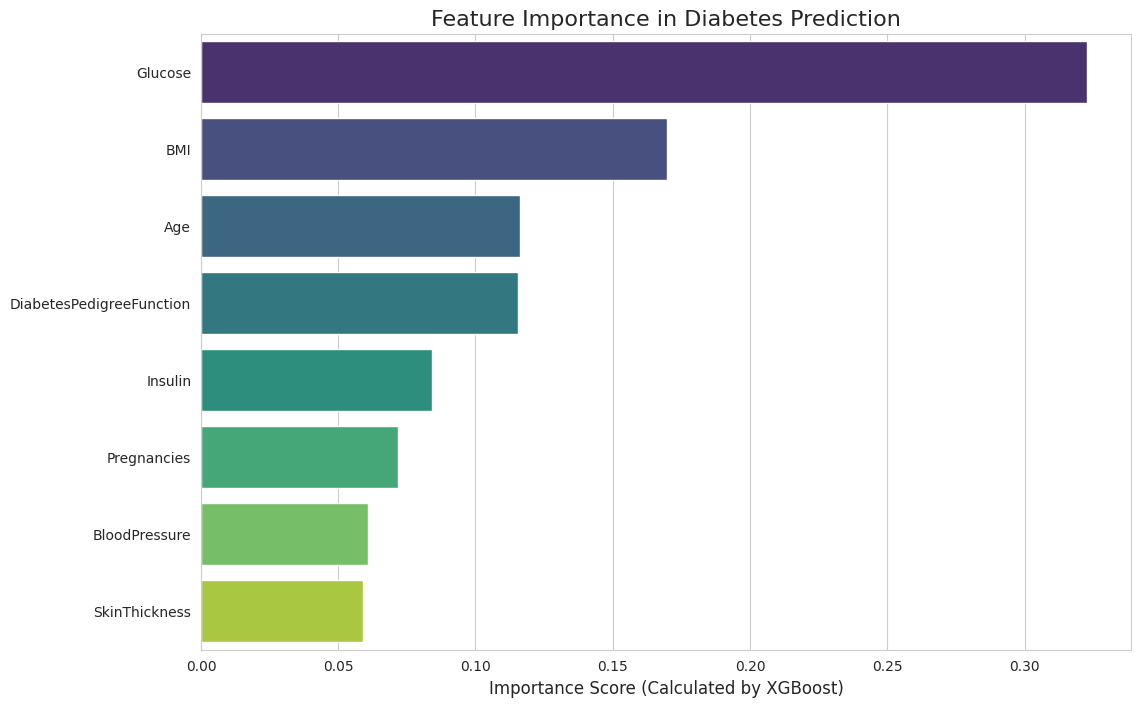

In [ ]:
sns.set_style('whitegrid')
plt.figure(figsize=(12,8))

barplot = sns.barplot(x='Importance', y ='Feature' , data = feature_importances_df,palette='viridis')

plt.title('Feature Importance in Diabetes Prediction', fontsize=16)

# Label the x-axis. It's good practice to specify what the importance score means.
plt.xlabel('Importance Score (Calculated by XGBoost)', fontsize=12)

# The y-axis label is clear from the feature names, but we can remove the default 'Feature' label for a cleaner look.
plt.ylabel('')

# iterate through each bars in ploit
for p in barplot.patches:
  width = p.get_width()

  plt.text(width+0.001,
           p.get_y()+p.get_height()/2,
           f'{width:.config}',
           va='center'
           )


  plt.show()


SHAP lib for adv MODEL INTERPRETATION
However, this global view has a fundamental limitation. It answers "what is important overall?" but it cannot answer a doctor's real-world question: "Why did the model flag this specific patient as high-risk?" The bar chart can't tell you if a patient's prediction was driven up by a single, extremely high Glucose reading, or by a combination of moderately high BMI and Age.

In [ ]:
!pip install shap


In [ ]:
import shap

#  create a SHAP explainer obj
# 2 argument 1. model to explain 'final_model' --> it will learn how to analyze the model
#  2. background dataset
explainer = shap.Explainer(final_model , X_train_scaled)

print("Explainer type:", type(explainer))


Explainer type: <class 'shap.explainers._tree.TreeExplainer'>


In [ ]:
shap_values = explainer(X_test)
print("--- SHAP Values Object ---")
print("Type of the output:", type(shap_values))

# Let's look at the shape of the SHAP values themselves.
# The .values attribute contains a NumPy array of the raw SHAP values.
# The shape will be (number of samples, number of features).
print("\nShape of the SHAP values array:", shap_values.values.shape)
print(f"This means we have {shap_values.values.shape[0]} explanations (one for each test patient),")
print(f"and each explanation has {shap_values.values.shape[1]} values (one for each feature).")

# You can also inspect the first row of SHAP values to see the explanation for the first patient in the test set.
print("\nSHAP values for the first patient in the test set:")
print(shap_values.values[0])

# The Explanation object also contains the original data used for the explanation.
print("\nOriginal feature values for the first patient:")
print(shap_values.data[0])

--- SHAP Values Object ---
Type of the output: <class 'shap._explanation.Explanation'>

Shape of the SHAP values array: (154, 8, 2)
This means we have 154 explanations (one for each test patient),
and each explanation has 8 values (one for each feature).

SHAP values for the first patient in the test set:
[[-0.04512466  0.04512466]
 [-0.16016827  0.16016826]
 [ 0.0124663  -0.0124663 ]
 [-0.01543741  0.01543741]
 [ 0.01559181 -0.01559181]
 [-0.09730388  0.09730388]
 [-0.02250192  0.02250192]
 [ 0.04788725 -0.04788725]]

Original feature values for the first patient:
[  7.    159.     64.     29.    125.     27.4     0.294  40.   ]


In [ ]:
print(X_train.shape)
print(X_train_scaled.shape)
rf_model.n_features_in_

(614, 8)
(614, 8)


8

--- Generating SHAP Summary Plot (Beeswarm) ---


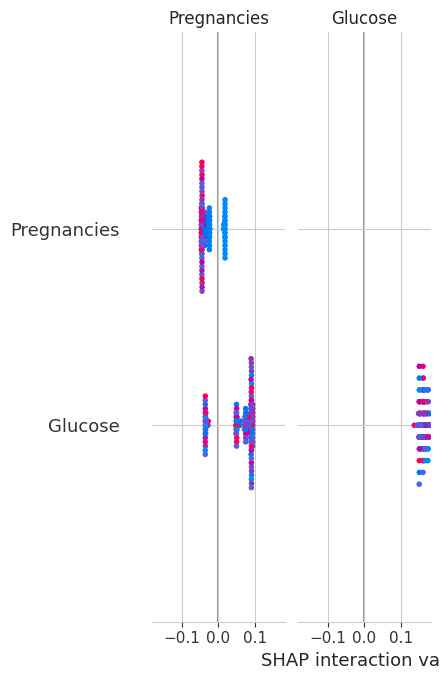

<Figure size 640x480 with 0 Axes>

In [ ]:
feature_names = X.columns # Assuming 'X' is the DataFrame of features before splitting

print("--- Generating SHAP Summary Plot (Beeswarm) ---")
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, plot_type="dot")

# The plot is automatically generated by the SHAP library, but you can add a title for context.
# We'll get the current figure and axes to add a title.
fig = plt.gcf()
fig.suptitle("SHAP Summary Plot for Diabetes Prediction", y=1.02, fontsize=16)

plt.show()

Plotting dependence for the most important feature: 'Glucose'
Coloring by the second most important feature: 'BMI'


ValueError: x and y must be the same size

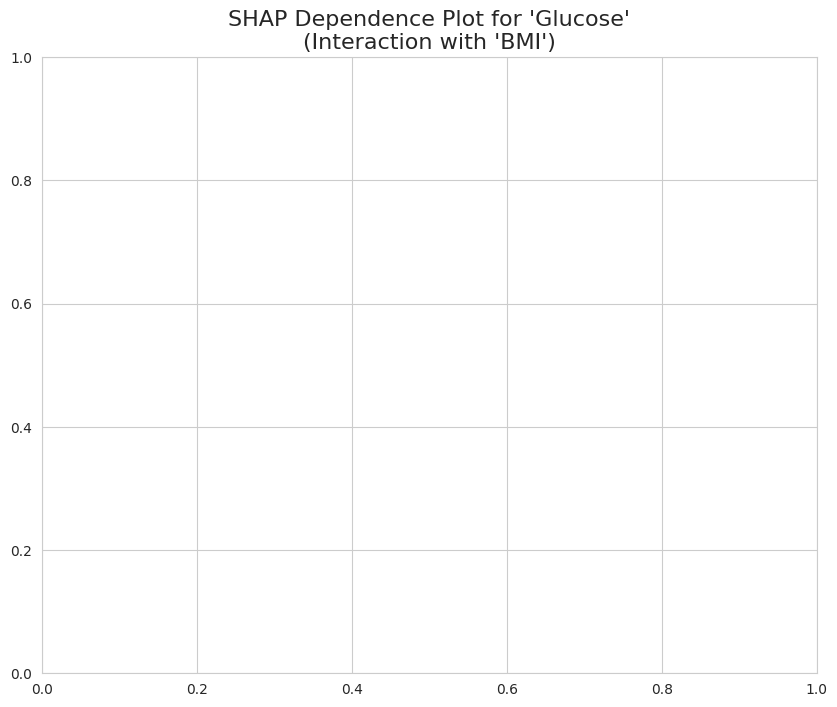

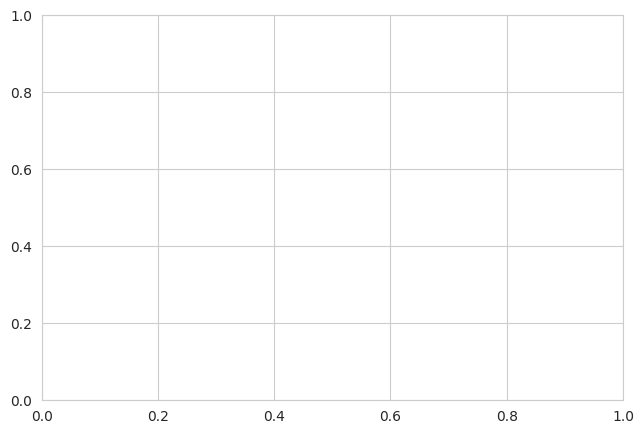

In [ ]:
most_important_feature = feature_importances_df.iloc[0]['Feature']
second_most_important_feature = feature_importances_df.iloc[1]['Feature']

print(f"Plotting dependence for the most important feature: '{most_important_feature}'")
print(f"Coloring by the second most important feature: '{second_most_important_feature}'")

plt.figure(figsize=(10, 8))
plt.title(f"SHAP Dependence Plot for '{most_important_feature}'\n(Interaction with '{second_most_important_feature}')", fontsize=16)

# Create the plot
shap.dependence_plot(
    most_important_feature,
    shap_values.values, # Use the .values attribute to pass the numpy array of SHAP values
    X_test_scaled,      # Pass the DataFrame of scaled test features
    interaction_index=second_most_important_feature,
    show=False # We set show=False to customize the plot further before displaying
)

# Customize the plot for better readability
plt.ylabel("SHAP Value (Impact on Model Output)")
plt.grid(True)
plt.show()


PREDICTION PIPELINE

In [ ]:
from sklearn.pipeline import Pipeline

Pipline consists of steps each step has tuple containing
1. name --> name of the step can be anything
2. estimator obj --> an instanve the actual sck learn obj that will perform work at this station

here we need Imputation station , scalling station , prediction station

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

try:
  final_model
except NameError :
  print("Warning: The 'final_model' variable is not defined.")
  print("Please make sure you have run the previous steps to get the best estimator from GridSearchCV.")


# pipe line steps

pipeline_steps = [
    # Missing values
    ('imputer', SimpleImputer(strategy='median')),

    # Scale the feature
    ('scaler', StandardScaler()),

    # final mode
    ('classifier', final_model)
]

print("--- Machine Learning Pipeline Blueprint ---")
for step in pipeline_steps:
    print(f"Step Name: '{step[0]}', Object: {step[1].__class__.__name__}")



--- Machine Learning Pipeline Blueprint ---
Step Name: 'imputer', Object: SimpleImputer
Step Name: 'scaler', Object: StandardScaler
Step Name: 'classifier', Object: RandomForestClassifier


Create instance of pipeline class

In [ ]:
final_pipeline = Pipeline(steps=pipeline_steps)

print("--- Machine Learning Pipeline Assembled Successfully ---")
print(final_pipeline)

--- Machine Learning Pipeline Assembled Successfully ---
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('classifier',
                 RandomForestClassifier(max_depth=10, max_features='log2',
                                        min_samples_split=5, n_jobs=-1,
                                        random_state=42))])


Trrain the Pipeline
1. Data enters the pipeline 'X_train' data is feed tp station 1
2. IMputer learns andTransforms analayzes X_train pipeline calls the .fit_transform() on imputer
3. data moves here to scaler
4. call the .fit_transform() on scaler
5. data arrives at the classifier along with u_train
6. Model learns calls .fit() on final_model

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv('/content/diabetes.csv')

cols_to_impute = ['Glucose','BloodPressure','SkinThickness', 'Insulin', 'BMI']

df[cols_to_impute] = df[cols_to_impute].replace(0, np.nan)

# 4. Separate features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# 5. Split into training and testing sets. This is the crucial step.
# We will use X_train and y_train, which have not been processed yet.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- Train the Pipeline ---
# This single .fit() command orchestrates the entire training process as described above.
# It will learn the imputation medians, scaling parameters, and model weights, all from X_train.
print("\nTraining the final_pipeline...")
final_pipeline.fit(X_train, y_train)



Training the final_pipeline...


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('classifier',
                 RandomForestClassifier(max_depth=10, max_features='log2',
                                        min_samples_split=5, n_jobs=-1,
                                        random_state=42))])

--- Pipeline Predictions on Raw Test Data Generated Successfully ---

--- Classification Report from Pipeline ---
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.78      0.84      0.81       100
    Diabetic (1)       0.65      0.56      0.60        54

        accuracy                           0.74       154
       macro avg       0.71      0.70      0.70       154
    weighted avg       0.73      0.74      0.73       154


--- Confusion Matrix from Pipeline ---


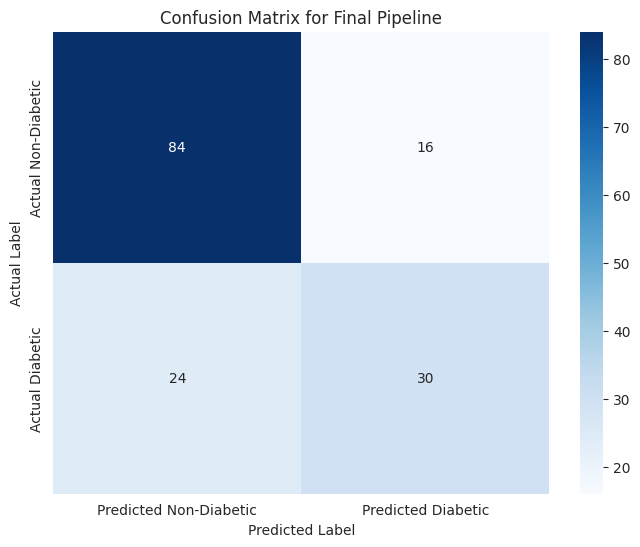



--- Sanity Check: Manual Workflow vs. Pipeline Workflow ---


,Original Random Forest,Final Tuned Random Forest,Pipeline Workflow
Metric,,,
F1-Score,0.6600,0.6275,0.6000
Recall,0.6111,0.5926,0.5556
False Negatives (Critical),21,22,24



Verification Result: The performance metrics should be IDENTICAL between the 'Final Tuned' model and the 'Pipeline'.
This proves our pipeline correctly encapsulates the entire workflow!


In [ ]:
# Import the necessary functions for evaluation and visualization
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- Step 1: Make Predictions Using the Trained Pipeline ---
# We feed the RAW X_test data directly to our trained pipeline.
# The pipeline will handle all the necessary preprocessing steps internally.
# The 'y_test' variable from the previous task's code should still be in memory.
y_pred_pipeline = final_pipeline.predict(X_test)

print("--- Pipeline Predictions on Raw Test Data Generated Successfully ---")

# --- Step 2: Generate the Classification Report ---
# This report shows us the precision, recall, and f1-score for the pipeline's performance.
print("\n--- Classification Report from Pipeline ---")
print(classification_report(y_test, y_pred_pipeline, target_names=['Non-Diabetic (0)', 'Diabetic (1)']))

# --- Step 3: Generate and Visualize the Confusion Matrix ---
print("\n--- Confusion Matrix from Pipeline ---")
cm_pipeline = confusion_matrix(y_test, y_pred_pipeline)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_pipeline,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Predicted Non-Diabetic', 'Predicted Diabetic'],
            yticklabels=['Actual Non-Diabetic', 'Actual Diabetic'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix for Final Pipeline')
plt.show()

# --- Step 4: The Ultimate Sanity Check ---
# Let's compare the pipeline's performance directly with the manually processed model's performance.
# We'll use the 'comparison_df' from the end of the tuning step.
print("\n\n--- Sanity Check: Manual Workflow vs. Pipeline Workflow ---")
try:
    # Get the key metrics from the pipeline's confusion matrix and report
    # Store the classification report in a variable first to use consistent target names
    pipeline_report = classification_report(y_test, y_pred_pipeline, output_dict=True, target_names=['Non-Diabetic (0)', 'Diabetic (1)'])

    pipeline_f1 = pipeline_report['Diabetic (1)']['f1-score']
    pipeline_recall = pipeline_report['Diabetic (1)']['recall']
    pipeline_fn = cm_pipeline[1, 0] # False Negatives

    # Add the pipeline's results to our previous comparison dataframe
    verification_df = comparison_df.copy() # Make a copy to preserve the original
    verification_df['Pipeline Workflow'] = [pipeline_f1, pipeline_recall, pipeline_fn]

    display(verification_df.style.format('{:.4f}', subset=pd.IndexSlice[['F1-Score', 'Recall'], :])
                             .format('{:.0f}', subset=pd.IndexSlice[['False Negatives (Critical)'], :])
                             .background_gradient(cmap='Greens', axis=1, subset=pd.IndexSlice[['F1-Score', 'Recall'], :])
                             .highlight_min(subset=pd.IndexSlice[['False Negatives (Critical)'], :], color='lightcoral', axis=1))

    print("\nVerification Result: The performance metrics should be IDENTICAL between the 'Final Tuned' model and the 'Pipeline'.")
    print("This proves our pipeline correctly encapsulates the entire workflow!")

except NameError:
    print("\n'comparison_df' not found. Please ensure you have run the final task of the 'Hyperparameter Tuning' step.")


Saving the Trained Pipeline:

joblib.dump() --> serialize the obj and save it into file
arg 1 : obj to save our fully trained final_pipeline
arg 2 : the path and file nameit to

In [ ]:
import joblib
import pandas as pd

#  save the trainded pipeline into file

pipeline_filename = 'diabetes_pipeline.joblib'

joblib.dump(final_pipeline, pipeline_filename)

# veriffy

print("\n\n--- Verification Step ---")
print("Loading the pipeline from the file to test it...")

# Load the pipeline from the file into a new variable.
loaded_pipeline = joblib.load(pipeline_filename)

print("Pipeline loaded successfully. Preparing a sample for prediction...")

# test ona sample data
sample_patient = X_test.iloc[[0]]
prediction = loaded_pipeline.predict(sample_patient)
prediction_probability = loaded_pipeline.predict_proba(sample_patient)

print("\n--- Prediction on a Sample Patient ---")
print("Sample Patient Data:")
display(sample_patient)
print(f"\nModel Prediction (0=Non-Diabetic, 1=Diabetic): {prediction[0]}")
print(f"Prediction Probabilities (for [Non-Diabetic, Diabetic]): {prediction_probability[0]}")




--- Verification Step ---
Loading the pipeline from the file to test it...
Pipeline loaded successfully. Preparing a sample for prediction...

--- Prediction on a Sample Patient ---
Sample Patient Data:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
44,7,159.0,64.0,NaN,NaN,27.4,0.294,40



Model Prediction (0=Non-Diabetic, 1=Diabetic): 1
Prediction Probabilities (for [Non-Diabetic, Diabetic]): [0.23461181 0.76538819]
